# Transport Properties using the Boltzmann Equation
**by <span style="color:darkgreen">Maria Troppenz</span> & <span style="color:darkgreen">Santiago Rigamonti</span> for [<span style="color:darkgoldenrod">exciting *sodium*</span>](https://www.exciting-code.org/sodium)**

<font size="2">(Jupyter notebook by <span style="color:darkgreen">Tejus Rohatgi</span>, <span style="color:darkgreen">Mara Voiculescu</span> & <span style="color:darkgreen">Martin Kuban</span>)</font>
<hr style="border:2px solid #DDD"> </hr>

**<span style="color:firebrick">Purpose</span>**:  In this tutorial you will learn how to calculate electronic transport coefficients with **`exciting`**. The coefficients are obtained by solving the linearized Boltzmann equation in the constant relaxation time approximation. They are calculated for bulk silicon.
<hr style="border:2px solid #DDD"> </hr>

<div class="alert alert-block alert-warning">

**Table of Contents**

[0. Before Starting](#0)

[1. Theoretical Background](#1)

[2. Transport coefficients of Bulk Silicon](#2)
   * [Preparation of the calculation](#2-1)
    
   * [Calculation of the transport coefficients at room temperature](#2-2)
    
   * [Calculation of the transport coefficients at different temperatures](#2-3)

</div>

<a id='0'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">0. Before Starting</span>

**<span style="color:firebrick">Read the following paragraphs before starting with the rest of this tutorial!</span>**

Before running any Jupyter tutorials, please refer to the **`00_before_starting.md`** document on how to correctly set up the environment. This only needs to be done once. After which, the **venv** can be (re)activated from **`exciting`**'s root directory:

<div style="background-color: rgb(224, 224, 224);">

```bash
source $EXCITINGROOT/tools/excitingjupyter/venv/excitingvenv/bin/activate
```

</div>

As a first step, you may create a running directory for the notebook.

<a id='1'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">1. Theoretical Background</span>

<hr style="border:1px solid #DDD"> </hr>

<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Transport coefficients by using the Boltzmann equation</span></strong> 
    
</summary>    

The electronic transport coefficients, evaluated in this tutorial, are the electrical conductivity *σ*, the Seebeck coefficient ***S***, and the electronic part of the thermal conductivity $\kappa_e$. They are related to the electronic structure of the material and directly affect the material's thermoelectric efficiency through the dimensionless figure of merit:

<a id='e1'></a>
\begin{equation}
\tag{1}
ZT=σS^2\kappa T 
\end{equation}

Here, T is the temperature and $\kappa$ the total thermal conductivity, which is given by the sum of electronic contribution $\kappa_e$ and the lattice contribution $\kappa_l$, i.e. $\kappa=\kappa_e+\kappa_l$. The product $σS^2$ is also called the power factor.

The transport coefficients are obtained by solving the linearized Boltzmann's equation in the relaxation time approximation (for further information see Ref. [[1]](#r1). The kernel of the transport coefficients is the transport distribution function,

<a id="e2"></a>
\begin{equation}
\tag{2}
\Xi(\epsilon) =\frac{1}{m^2_e}\sum_{n\pmb{k}} \pmb{p}_{n\pmb{k}}\pmb{p}_{n\pmb{k}}\tau_{n\pmb{k}}δ(\epsilon−\epsilon_{n\pmb{k}}) 
\end{equation}

It is a tensor and depends on the carrier's relaxation time $\tau_{n\pmb{k}}$the dyadic product of the charge carrier's momentum matrix elements $\pmb{p}_{n\pmb{k}}$($m_e$ the electron mass). The sum is over all states with the band index $n$ and the wave vector $\pmb{k}$ in the first Brillouin Zone. In the constant relaxation time approximation, $\tau$ is independent from $n$ and $\pmb{k}$ and the transport distribution function is:

<a id='e3'></a>
\begin{equation}
\tag{3}
\Xi(\epsilon) =\frac{\tau}{m^2_e}\sum_{n\pmb{k}} \pmb{p}_{n\pmb{k}}\pmb{p}_{n\pmb{k}}δ(\epsilon−\epsilon_{n\pmb{k}}) 
\end{equation}

Using Eq. [(2)](#e2), the transport coefficients can be calculated as follows:

<a id='e4'></a>
\begin{equation}
\tag{4}
\pmb{\sigma}(T,\mu)= e^2 \int d\epsilon \left(-\frac{\partial{f_0 (T,\mu)}}{\partial{\epsilon}}\right) \Xi(\epsilon) 
\end{equation}
<a id='e5'></a>
\begin{equation}
\tag{5}
\pmb{S}(T,\mu)= \frac{ek_B}{\sigma} \int d\epsilon \left(-\frac{\partial{f_0 (T,\mu)}}{\partial{\epsilon}}\right) \Xi(\epsilon) \frac{\epsilon - \mu}{k_BT}
\end{equation}
<a id='e6'></a>
\begin{equation}
\tag{6}
\pmb{\kappa_0}(T,\mu)=k_b^2T \int d\epsilon \left(-\frac{\partial{f_0 (T,\mu)}}{\partial{\epsilon}}\right) \Xi(\epsilon) \left(\frac{\epsilon - \mu}{k_BT}\right)^2
\end{equation}

Here, μ is the chemical potential, $e$ the electron charge, and $−\frac{\partial{f_0}}{\partial{\epsilon}}$ the derivative of the Fermi distribution function

<a id='e7'></a>
\begin{equation}
\tag{7}
f_0(T,\mu)=\frac{1}{[exp(\epsilon−\mu)/k_BT]+1}
\end{equation}

with respect to the energy $\epsilon$. $\kappa_0$ is the electronic part of the thermal conductivity for zero electrochemical potential gradient inside the sample, while the conventional electronic part of thermal conductivity, $\kappa_e$, is defined for zero electric current and is obtained by the relation $\kappa_e = \kappa_0 - T\sigma S^2$. The lattice part of the thermal conductivity still remains to be calculated by other methods.

Details about the method and its first *ab initio* implementation can be found in **Refs. [[2]](#r2)** and **[[3]](#r3)**.
    
</details>    

<a id='2'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">2. Transport coefficients of Bulk Silicon</span>

To start the tutorial, create a new, empty directory named BE-Si and move into it.

In [1]:
%%bash
mkdir -p BE-Si

<a id='2-1'></a>
#### <span style="color:#15317E">i) Preparation of calculation</span>

Save the following lines as <b>input.xml</b>:

<span class="BULK_SILICON_INPUT"></span>
```xml
<input>
   <title>Bulk Silicon</title>
   <structure speciespath="$EXCITINGROOT/species/">
      <crystal scale="10.26">
         <basevect>0.0   0.5   0.5</basevect>
         <basevect>0.5   0.0   0.5</basevect>
         <basevect>0.5   0.5   0.0</basevect>
      </crystal>
      <species speciesfile="Si.xml">
         <atom coord="0.00  0.00  0.00"></atom>
         <atom coord="0.25  0.25  0.25"></atom>
      </species>
   </structure>
   <groundstate
      do="fromscratch"
      xctype="GGA_PBE_SOL"
      ngridk="4 4 4"
      rgkmax="8.0"
      gmaxvr="14.0"
      maxscl="100">
   </groundstate>
</input>
```

In [2]:
from excitingjupyter.utilities import get_input_xml_from_notebook

input_str = get_input_xml_from_notebook("transport_properties_using_the_boltzmann_equation", "BULK_SILICON_INPUT")

# Write out the input as an XML file:
with open('./BE-Si/input.xml', "w") as fid:
    fid.write(input_str)

Set up <code><span style="color:mediumblue">$EXCITINGROOT</span></code> to the correct root directory in <code><span style="color:mediumblue">speciespath</span></code> and execute **`exciting_smp`** with the commands

In [3]:
%%bash
cd BE-Si
python3 -m excitingscripts.setup.excitingroot
time $EXCITINGROOT/install/bin/exciting_smp input.xml
cd ..

 ### Using specified input file: input.xml


   Elapsed time = 0m4s


To gain a better understanding of the later calculated transport coefficients of silicon, you may want to look at the band structure. For this, please expand the link below and follow the instructions.

<hr style="border:1px solid #DDD"> </hr>
<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Calculation of the bandstructure of bulk silicon</span></strong> 
    
</summary>    
    
Add the element properties in your **input.xml** with the following lines

```xml
    <properties>
      <bandstructure>
         <plot1d>
            <path steps="300">
               <point coord="1.0     0.0     0.0" label="Gamma"/>
               <point coord="0.625   0.375   0.0" label="K"/>
               <point coord="0.5     0.5     0.0" label="X"/>
               <point coord="0.0     0.0     0.0" label="Gamma"/>
               <point coord="0.5     0.0     0.0" label="L"/>
            </path>
         </plot1d>
      </bandstructure> 
   </properties>
```
and <b>execute </b> again.
```
$ time 
```
    
After the calculation finished, you can visualize the band structure with the commands
```
$ python3 -m excitingscripts.plot.bandstructure -e -15 10
```

For a detailed explanation of calculating the band structure, see the tutorial [<span style="color:firebrick"><b>Electronic band-structure and density of states</b></span>](https://www.exciting-code.org/uploads/exciting/tutorial_notebooks/tutorial_electronic_band-structure_and_density_of_states.html).
</details>  

<a id='2-2'></a>
<hr style="border:1px solid #DDD"> </hr>   

#### <span style="color:#15317E">ii) Calculation of the transport coefficients at room temperature
    
In the following, we calculate the transport coefficients with respect to the chemical potential at a constant temperature (here 300K). The equations of the transport coefficients (see <span style="color:red">**Section 1**</span>) contain the derivative of the Fermi distribution function $f_0$. That means that only **k**-points with eigenenergies near the Fermi surface contribute to the coefficients. In order to achieve a sufficient representation of the energy bands in this area, a fine **k**-grid is needed.

To obtain eigenenergies for a fine **k**-grid, we perform a single self-consistency loop on top of the previous ground-state calculation by changing in **input.xml**
* the attribute <code><span style="color:mediumblue">do</span></code> = <code><span style="color:#ae3931">"fromfile"</span></code>;
* the attribute <code><span style="color:mediumblue">ngridk</span></code> = <code><span style="color:#ae3931">"40 40 40"</span></code>;
* the attribute <code><span style="color:mediumblue">maxscl</span></code> = <code><span style="color:#ae3931">"1"</span></code>
    
in the element <code><span style="color:green">groundstate</span></code> (for more details see [<span style="color:firebrick"><b>Input Reference</b></span>](https://www.exciting-code.org/home/about/input-reference)).

The element <code><span style="color:green">groundstate</span></code> in **input.xml** should now look like this:

```xml
 ...
   <groundstate
      do="fromfile"
      xctype="GGA_PBE_SOL"
      ngridk="40 40 40"
      rgkmax="8.0"
      gmaxvr="14.0"
      maxscl="1">
   </groundstate>
...
```

In order to calculate the transport coefficients, <span style="color:red">**delete**</span> in your **input.xml** the "old" <code><span style="color:green">properties</span></code> block that you used for calculating the electronic band-structure:

```xml
   <properties>
 
      <bandstructure>
         ...
      </bandstructure>
 
   </properties>
```
and <span style="color:red">**substitute**</span> it with

<span class="TRANSPORT_PROPERTIES_INPUT"></span>
```xml
<properties>
 
      <momentummatrix/>
      <boltzequ
         energyReference="efermi"
         transportDfRange="-0.5 0.5"
         transportDfSpacing="0.001"
         temperatureRange="300 300"
         temperatureSpacing="1"
         chemicalPotentialRange="-0.05 0.05"
         chemicalPotentialSpacing="0.0001"
         evOutputEnergies="true"
         siOutputUnits="true">
         <etCoeffComponents>1 1</etCoeffComponents>
         <etCoeffComponents>2 2</etCoeffComponents>
         <etCoeffComponents>3 3</etCoeffComponents>     
      </boltzequ>
 
</properties>
```

With inserting the element <code><span style="color:green">momentummatrix</span></code>, the momentum matrix elements are calculated. Inside the element <code><span style="color:green">boltzequ</span></code>, you define the attributes needed for the calculation of the transport coefficients.

An explanation of the attributes can be found by expanding the link below or in [<span style="color:firebrick"><b>Input Reference</b></span>](https://www.exciting-code.org/home/about/input-reference).

In [5]:
# The following lines modify the input.xml using Python
from excitingtools import ExcitingInputXML, ExcitingPropertiesInput

parsed_input = ExcitingInputXML.from_xml('./BE-Si/input.xml')

properties= {'momentummatrix': {},
             'boltzequ': {'energyReference': 'efermi',
             'transportDfRange': [-0.5, 0.5],
             'transportDfSpacing': 0.001,
             'temperatureRange': [300, 300],
             'temperatureSpacing': 1,
             'chemicalPotentialRange': [-0.05, 0.05],
             'chemicalPotentialSpacing': 0.0001,
             'evOutputEnergies': True,
             'siOutputUnits': True,
             'etCoeffComponents': [[1, 1], [2, 2], [3, 3]]}}

parsed_input.properties = ExcitingPropertiesInput(**properties)
parsed_input.groundstate.do = "fromfile"
parsed_input.groundstate.ngridk = [40, 40, 40]
parsed_input.groundstate.maxscl = 1


parsed_input.write('./BE-Si/input.xml')

<hr style="border:1px solid #DDD"> </hr>
<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Table of the attributes used for the transport coefficients</span></strong></summary> 
    
Attribute | Element | Description 
:--- | :--- | :--- 
<code><span style="text-align: left;  color:blue">energyReference</span></code> | <code><span style="text-align: left; color:green">boltzequ</span></code> | <span style="text-align: left;">If <code><span style="color:#ae3931">"efermi"</span></code>, the energy inputs are given with respect to the Fermi energy. Else <span style="color:#ae3931">"none"</span></code>.
<code><span style="text-align: left;  color:blue">useTransportDf</span></code> | <code><span style="text-align: left; color:green">boltzequ</span></code> | <span style="text-align: left;">If <code><span style="color:#ae3931">"true"</span></code> (default), the transport coefficients are calculated with the kernel function, the transport distribution function.
<code><span style="text-align: left;  color:blue">transportDfRange</span></code> | <code><span style="text-align: left; color:green">boltzequ</span></code> | <span style="text-align: left;">Frequency (or energy) range for which the transport distribution function $\Xi(\epsilon)$ (See Eq. <a href="#e2">(2)</a> in <span style="color:red"><b>Section 1</b></span>) is calculated.
<code><span style="text-align: left;  color:blue">transportDfSpacing</span></code> | <code><span style="text-align: left; color:green">boltzequ</span></code> | <span style="text-align: left;">Spacing between the frequency (or energy) points used for the evaluation of the transport distribution function.
<code><span style="text-align: left;  color:blue">temperatureRange</span></code> | <code><span style="text-align: left; color:green">boltzequ</span></code> | <span style="text-align: left;">Temperature range in Kelvin for which the transport coefficients are calculated.
<code><span style="text-align: left;  color:blue">temperatureSpacing</span></code> | <code><span style="text-align: left; color:green">boltzequ</span></code> | <span style="text-align: left;">Spacing between temperature points in Kelvin.
<code><span style="text-align: left;  color:blue">chemicalPotentialRange</span></code> | <code><span style="text-align: left; color:green">boltzequ</span></code> | <span style="text-align: left;">Chemical potential range for which the transport coefficients are calculated.
<code><span style="text-align: left;  color:blue">chemicalPotentialRange</span></code> | <code><span style="text-align: left; color:green">boltzequ</span></code> | <span style="text-align: left;">Spacing between the chemical potential points.
<code><span style="text-align: left;  color:blue">useDopingConcentration</span></code> | <code><span style="text-align: left; color:green">boltzequ</span></code> | <span style="text-align: left;">If <code><span style="color:#ae3931">"true"</span></code>, the chemical potential is adjusted to the doping concentration. Input parameters for the chemical potential are discarded.
<code><span style="text-align: left;  color:blue">dopingConcentration</span></code> | <code><span style="text-align: left; color:green">boltzequ</span></code> | <span style="text-align: left;">Doping concentration in cm<sup>-3</sup>.
<code><span style="text-align: left;  color:blue">evOutputEnergies</span></code> | <code><span style="text-align: left; color:green">boltzequ</span></code> | <span style="text-align: left;">If <code><span style="color:#ae3931">"true"</span></code>, output energies are in eV.
<code><span style="text-align: left;  color:blue">siOutputUnits</span></code> | <code><span style="text-align: left; color:green">boltzequ</span></code> | <span style="text-align: left;">If <code><span style="color:#ae3931">"true"</span></code>, output transport coefficients are given in SI units: Seebeck coefficient in V/K, electrical conductivity over relaxation time in S/(m s), thermal conductivity over relaxation time in W/(m K s).

Using the element <code><span style="color:green">etCoeffComponents</span></code>, you specify the tensor component for which the transport coefficients are calculated. The element <code><span style="color:green">etCoeffComponents</span></code> needs, as input, an integer pair, e.g., <code><span>1 1</span></code> stands for the first diagonal component of the tensor ( <code><span>1</span></code> = x-direction, <code><span>2</span></code> = y-direction, and <code><span>3</span></code> = z-direction). 
    
</details>
<hr style="border:1px solid #DDD"> </hr>

By executing **`exciting_smp`**

In [6]:
%%bash
cd BE-Si
time $EXCITINGROOT/install/bin/exciting_smp input.xml
cd ..

 ### Using specified input file: input.xml
 ### Using specified input file: input.xml
 
Info(writepmat):
  Momentum matrix elements written to file PMAT.OUT
 
 ### Using specified input file: input.xml
  Transport distribution of component 11 written to TD_11.OUT
  Electrical conductivity over tau (sigma/tau) of component 11 written to ELECTCOND_11.OUT
  Seebeck coefficient (S) of component 11 written to SEEBECK_11.OUT
  Thermal conductivity over tau (kappa/tau) of component 11 written to THERMALCOND_11.OUT
  Figure of merit Z of component 11 written to Z_11.OUT
 
  Transport distribution of component 22 written to TD_22.OUT
  Electrical conductivity over tau (sigma/tau) of component 22 written to ELECTCOND_22.OUT
  Seebeck coefficient (S) of component 22 written to SEEBECK_22.OUT
  Thermal conductivity over tau (kappa/tau) of component 22 written to THERMALCOND_22.OUT
  Figure of merit Z of component 22 written to Z_22.OUT
 
  Transport distribution of component 33 written to TD_33.OU

   Elapsed time = 3m30s


the Seebeck coefficient $S$, the electrical conductivity over the relaxation time $\sigma/\tau$, and the thermal conductivity over the relaxation time $\kappa_0/\tau$ are calculated for the temperature range and chemical potential range defined in **input.xml**. They are found in the files <code>SEEBECK_<span style="color:mediumblue">*COMP*</span>.OUT</code>, <code>ELECTCOND_<span style="color:mediumblue">*COMP*</span>.OUT</code>, and <code>THERMALCOND_<span style="color:mediumblue">*COMP*</span>.OUT</code>, respectively, where, <code><span style="color:mediumblue">*COMP*</span></code> denotes the tensor component specified by the integer pair given in <code><span style="color:green">condcomp</span></code>. Furthermore, the figure of merit estimated by $Z=(\sigma S^2/\kappa_0)$ can be found in file <code>Z_<span style="color:mediumblue">*COMP*</span>.OUT</code>.

**<span style="color:red">Please note</span>**: $\sigma$ and $\kappa_0$ are not directly given, but the output files contain the coefficients $\sigma/\tau$ and $\kappa_0/\tau$. $\tau$ itself is constant (does not depend on electronic structure with $\pmb{k}$ and n), and can be multiplied afterwards.

Now, the transport coefficients are calculated and you can plot them by using  **`excitingscripts.plot.files`**.

The Seebeck coefficient at the temperature of 300K can be visualized with the following commands:

In [8]:
%%bash
cd BE-Si
cp SEEBECK_11.OUT S11
cp SEEBECK_22.OUT S22
cp SEEBECK_33.OUT S33
python3 -m excitingscripts.plot.files -f S11 S22 S33  -cx 2  -cy 3  -ll '$S_{xx}$' '$S_{yy}$' '$S_{zz}$'  -x -1 1  -lx '$\mu$ [eV]'  -ly 'S [$\mu$V/K]'  -ys 1e6  -rp
cd ..

The output is saved in `PLOT.png` and looks as follows:

<figure>
<img src=" 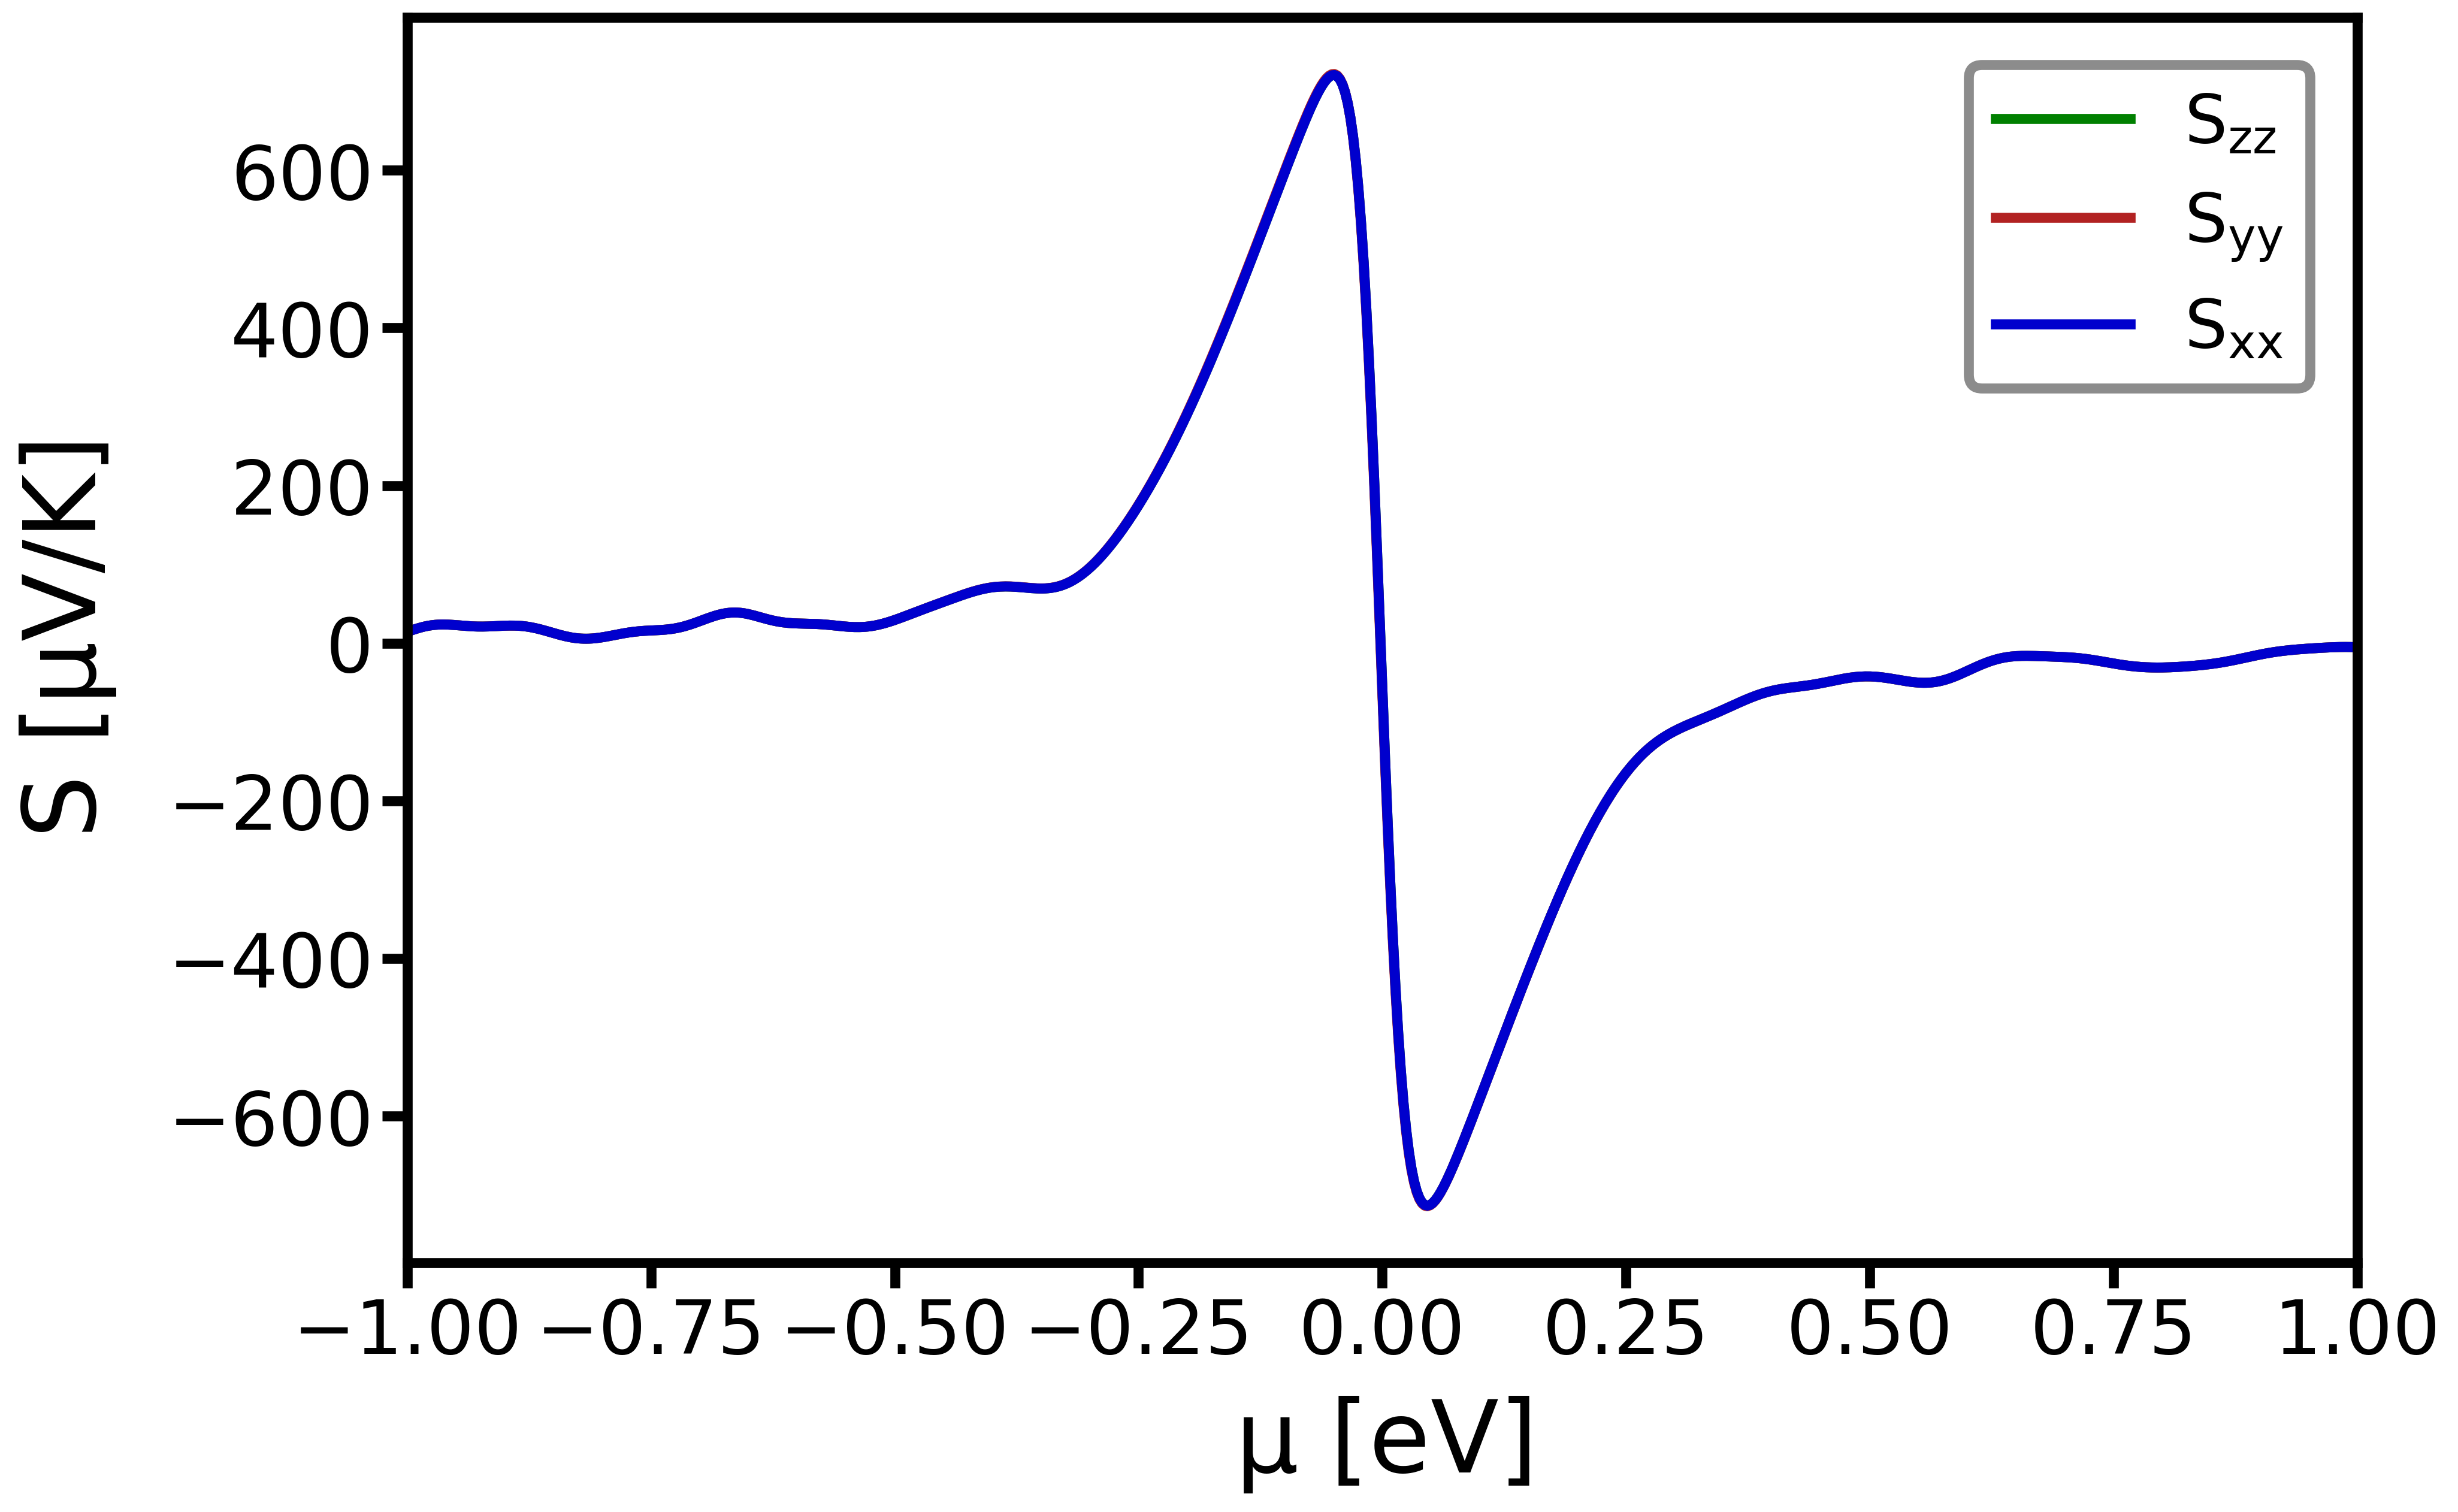" width="600" align="left"/>
</figure>

Assuming a <span style="color:red">**relaxation time $\tau$ of 10 fs**</span>, the electrical conductivity can be obtained as:

In [9]:
%%bash
cd BE-Si
cp ELECTCOND_11.OUT E11
cp ELECTCOND_22.OUT E22
cp ELECTCOND_33.OUT E33
python3 -m excitingscripts.plot.files -f E11 E22 E33  -cx 2  -cy 3  -ll '$\sigma_{xx}$' '$\sigma_{yy}$' '$\sigma_{zz}$'  -x -0.5 0.5  -y 0 9000  -lx '$\mu$ [eV]'  -ly '$\sigma$ [S/cm]'  -ys 1e-16  -lp 'upper center'  -rp  -mty 5
cd ../

Output:

<figure>
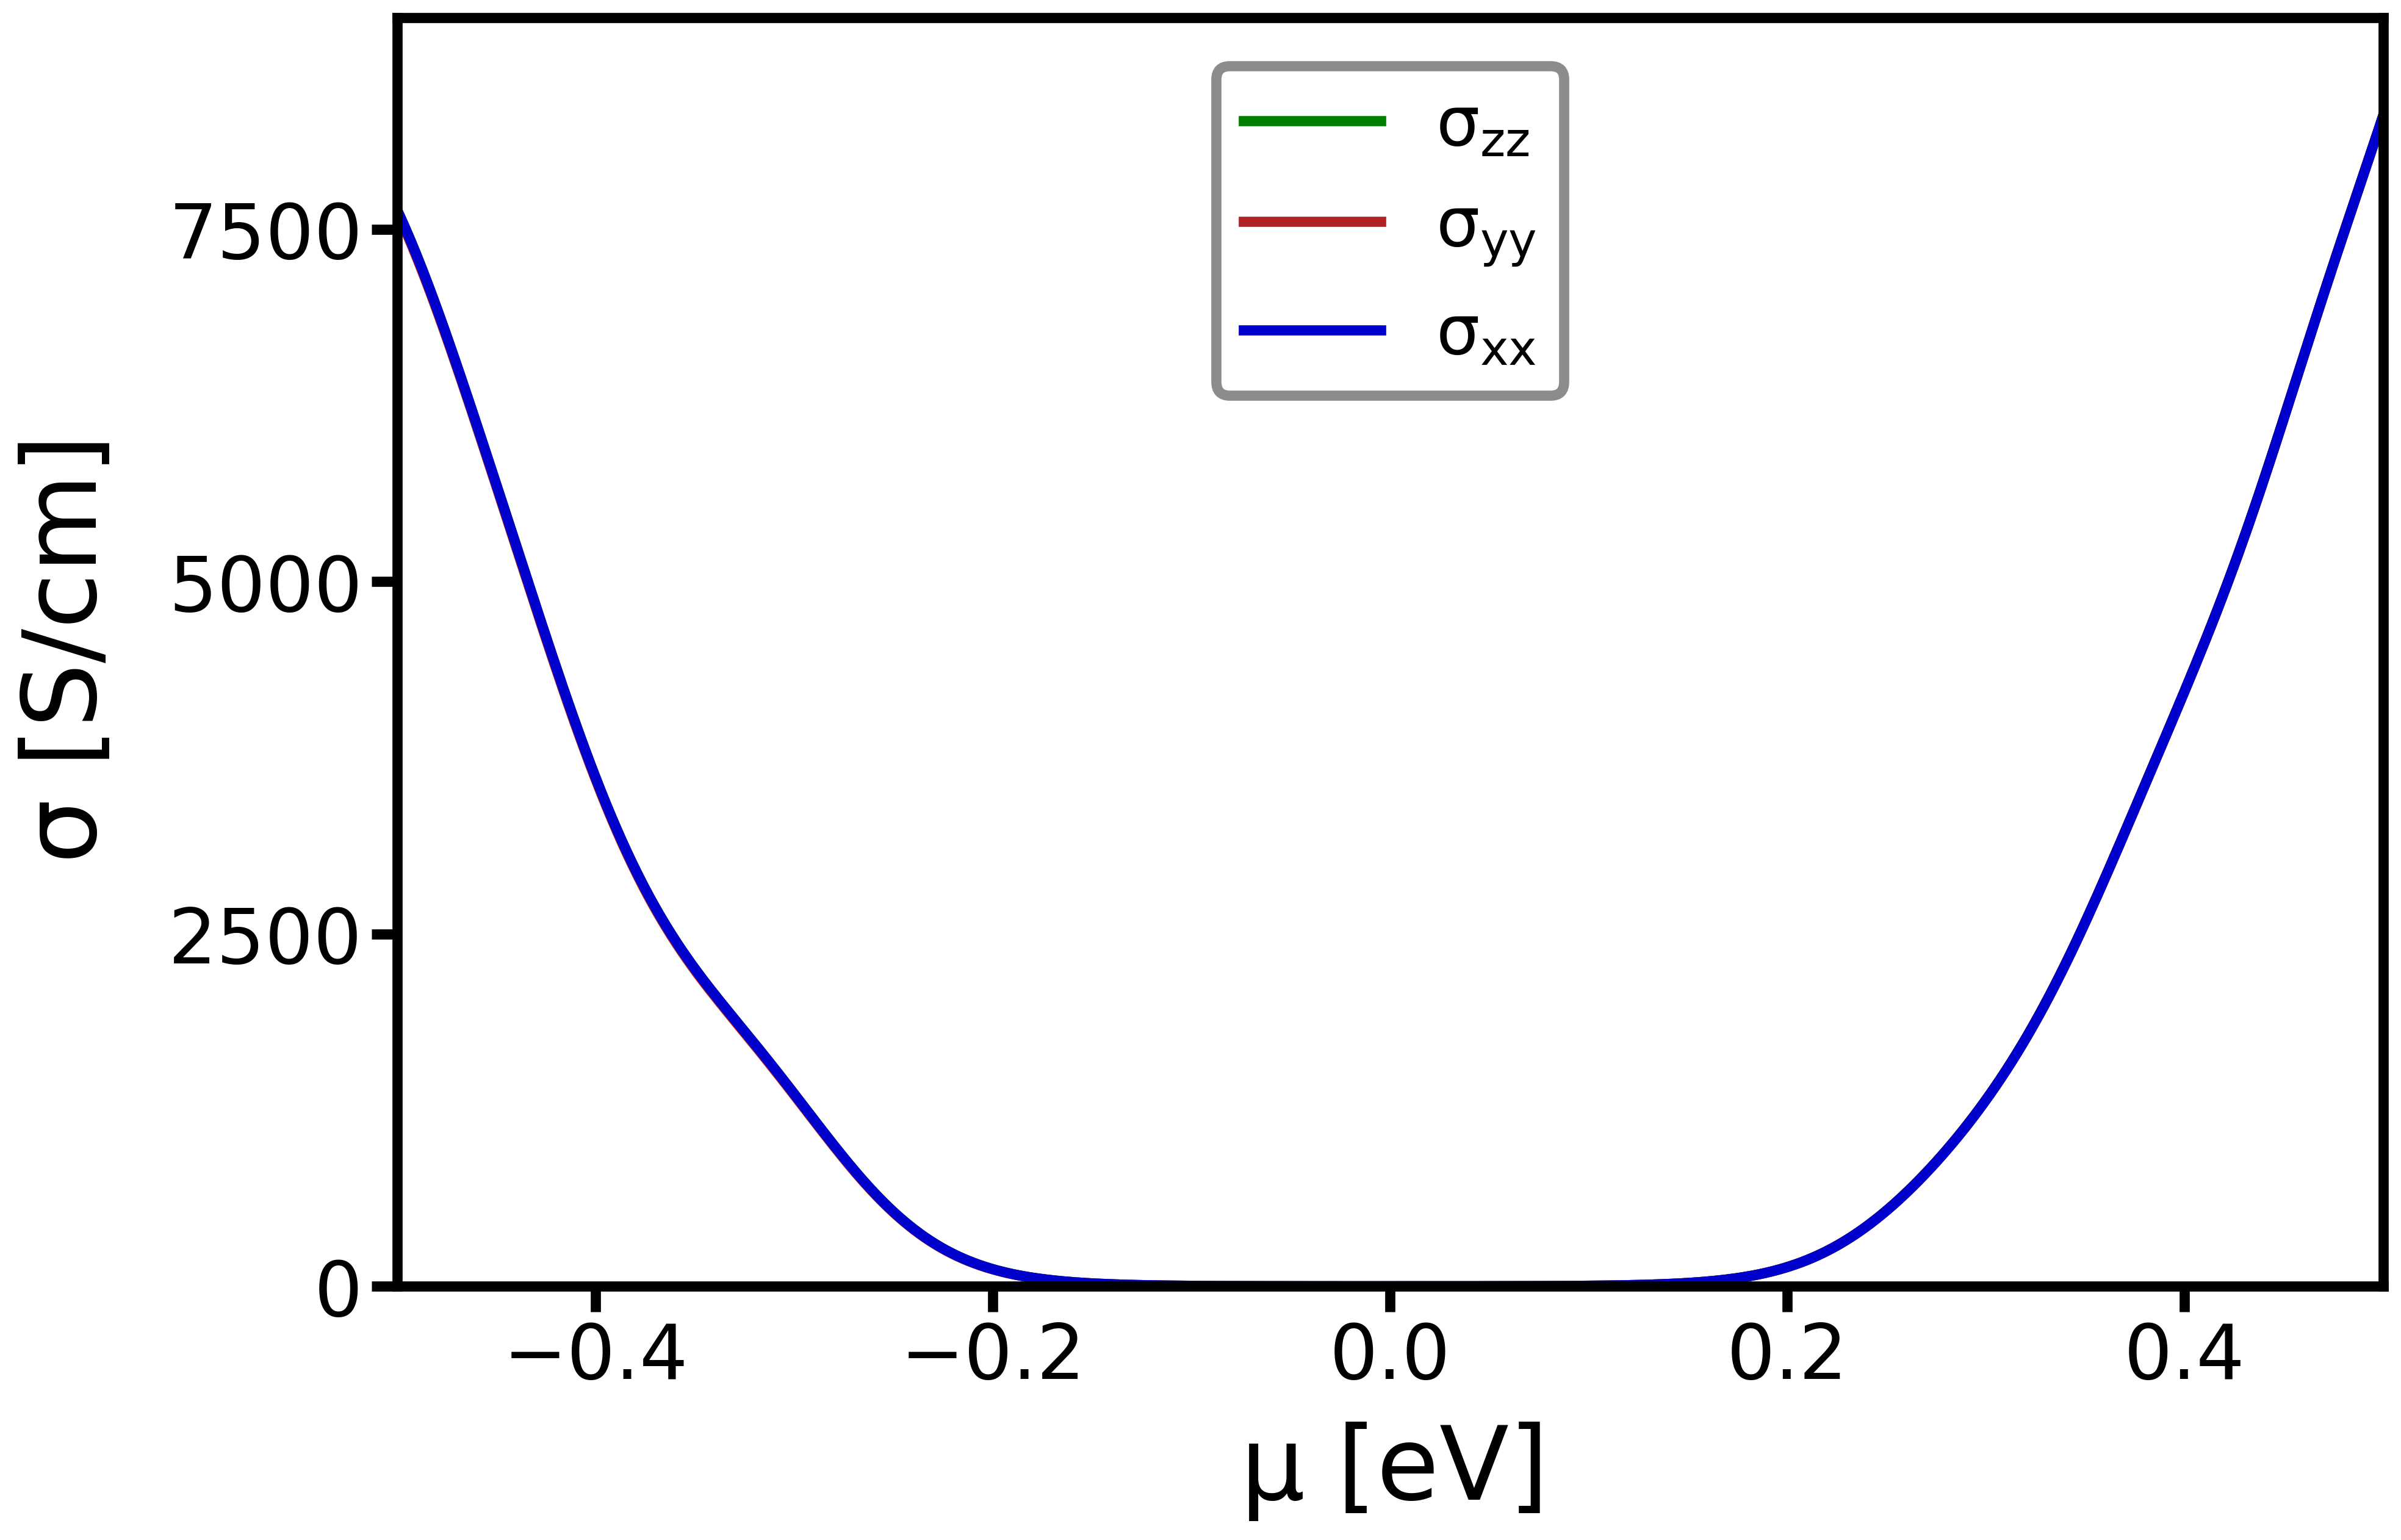
</figure>

And the corresponding power factor looks as:

In [10]:
%%bash
cd BE-Si
paste ELECTCOND_11.OUT SEEBECK_11.OUT | awk '{ printf $1 "\t" $2 "\t" $3*$7*$7 "\n" }' > PF11
paste ELECTCOND_22.OUT SEEBECK_22.OUT | awk '{ printf $1 "\t" $2 "\t" $3*$7*$7 "\n" }' > PF22
paste ELECTCOND_33.OUT SEEBECK_33.OUT | awk '{ printf $1 "\t" $2 "\t" $3*$7*$7 "\n" }' > PF33
python3 -m excitingscripts.plot.files -f PF11 PF22 PF33  -cx 2  -cy 3  -ll '${\sigma S^2}_{xx}$' '${\sigma S^2}_{yy}$' '${\sigma S^2}_{zz}$'  -x -0.5 0.5  -y 0 20  -lx '$\mu$ [eV]'  -ly '$\sigma S^2$ [$\mu W\,cm^{-1}\,K^{-2}$]'  -ys 1e-10  -lp 'upper center'  -rp
cd ../

Output:

<figure>
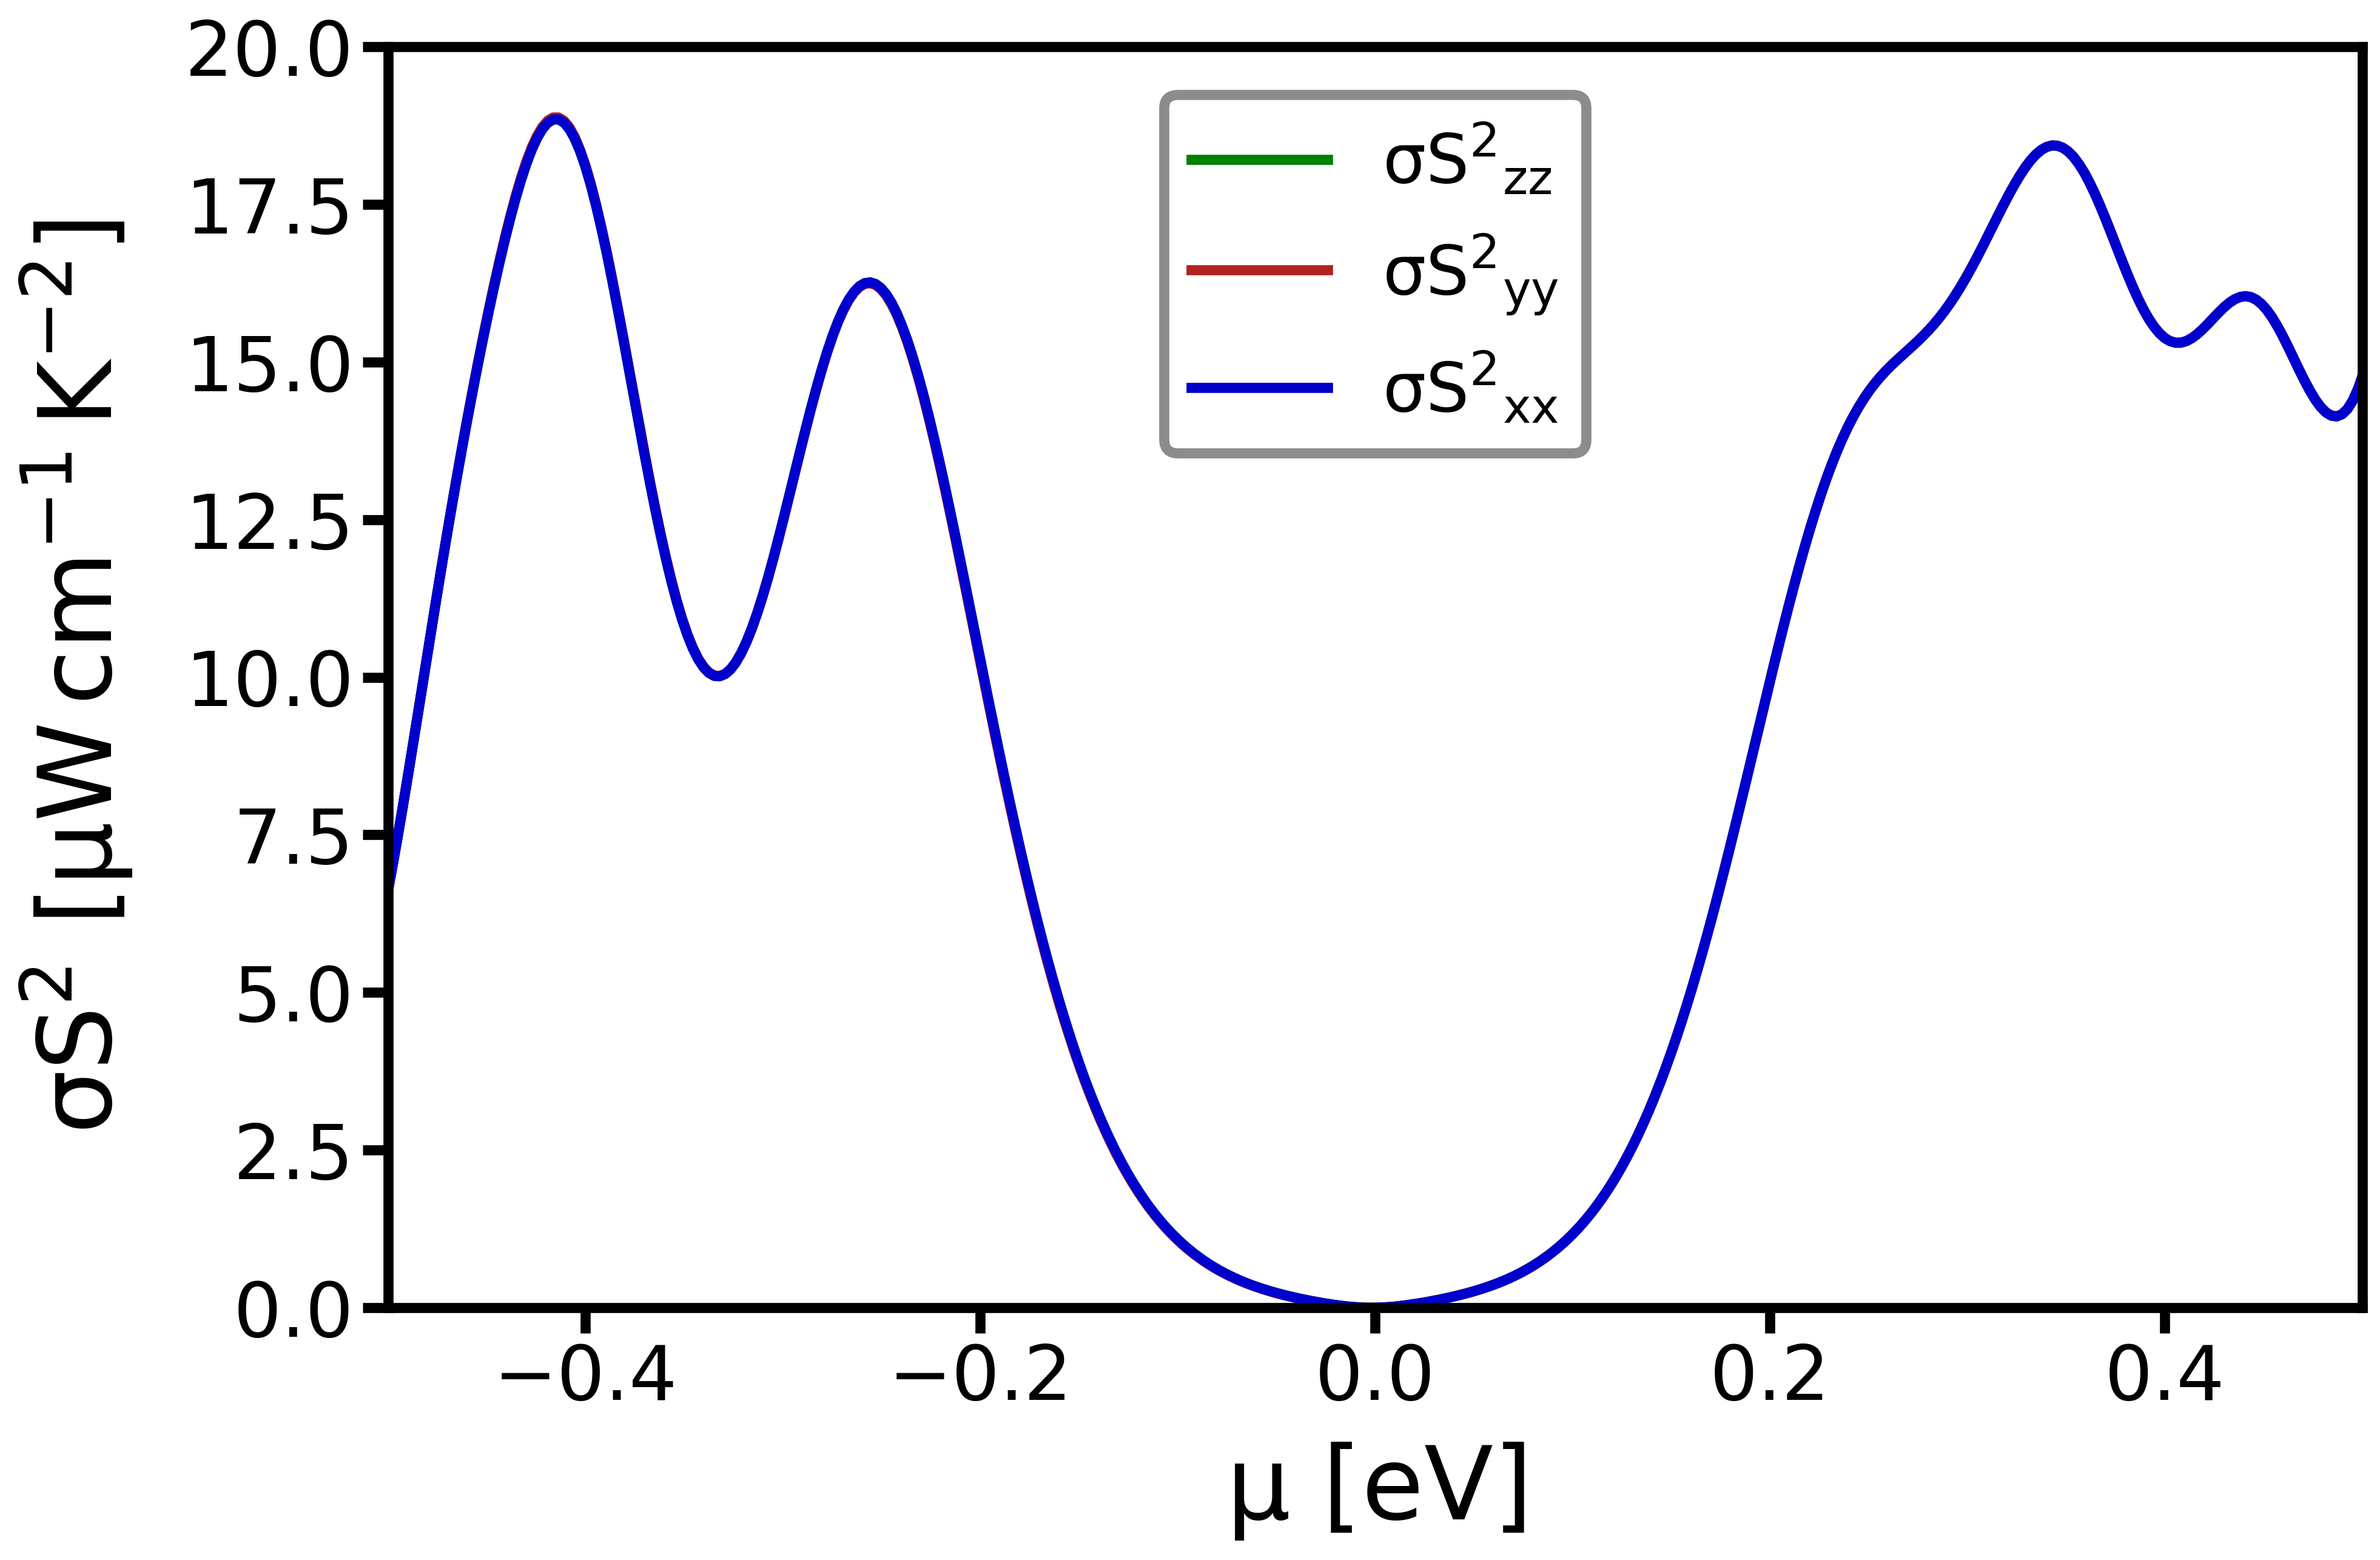
</figure>

<a id='2-3'></a>
<hr style="border:1px solid #DDD"> </hr>

#### <span style="color:#15317E">iii) Calculation of the transport coefficients at different temperatures

In the following, we look at the temperature dependence of transport coefficients at a constant chemical potential.

We can use the fine **k**-grid obtained in part <b>ii)</b> and skip the ground-state calculation by changing in <b>input.xml</b>

* The attribute <code><span style="color:mediumblue">do</span></code> to **"skip"** in the element <code><span style="color:green">groundstate</span></code>
* The momentum matrix elements does not need to be calculated again and, *e.g.*, can be removed or commented.

The element <code><span style="color:green">properties</span></code> of your **input.xml** can be changed to

<span class="TRANSPORT_PROPERTIES_WITH_TEMP_INPUT"></span>
```xml
<properties>
 
  <!--momentummatrix/-->
  <boltzequ
     energyReference="efermi"
     transportDfRange="-0.5 0.5"
     transportDfSpacing="0.001"
     temperatureRange="300 1200"
     temperatureSpacing="10"
     chemicalPotentialRange="-0.005 0.005"
     chemicalPotentialSpacing="0.005"
     evOutputEnergies="true"
     siOutputUnits="true">
     <etCoeffComponents>1 1</etCoeffComponents>
  </boltzequ>
 
</properties>
```
```xml
<properties>
 
      <momentummatrix/>
      <boltzequ
         energyReference="efermi"
         transportDfRange="-0.5 0.5"
         transportDfSpacing="0.001"
         temperatureRange="300 300"
         temperatureSpacing="1"
         chemicalPotentialRange="-0.05 0.05"
         chemicalPotentialSpacing="0.0001"
         evOutputEnergies="true"
         siOutputUnits="true">
         <etCoeffComponents>1 1</etCoeffComponents>
         <etCoeffComponents>2 2</etCoeffComponents>
         <etCoeffComponents>3 3</etCoeffComponents>     
      </boltzequ>
 
</properties>
```

The transport coefficients are calculated from 300 to 1200 K and for the chemical potentials $\mu = -0.136$ eV, 0 eV, and $0.136$ eV with respect to the Fermi energy. Here, we compute only the <code><span>1 1</span></code>-component of the transport coefficient's tensor. With the modified **input.xml**, we can rerun **`exciting_smp`**

In [11]:
%%bash

cd BE-Si
sed -i 's/temperatureRange="300 300"/temperatureRange="300 1200"/g' input.xml
sed -i 's/temperatureSpacing="1"/temperatureSpacing="10"/g' input.xml
sed -i 's/chemicalPotentialRange="-0.05 0.05"/chemicalPotentialRange="-0.005 0.005"/g' input.xml
sed -i 's/chemicalPotentialSpacing="0.0001"/chemicalPotentialSpacing="0.005"/g' input.xml
sed -i '/<etCoeffComponents>2 2<\/etCoeffComponents>/d' input.xml
sed -i '/<etCoeffComponents>3 3<\/etCoeffComponents>/d' input.xml
sed -i 's|<momentummatrix/>|<!--momentummatrix/-->|g' input.xml

cd ../

In [12]:
%%bash
cd BE-Si
time $EXCITINGROOT/install/bin/exciting_smp &
cd ../

  Transport distribution of component 11 written to TD_11.OUT
  Electrical conductivity over tau (sigma/tau) of component 11 written to ELECTCOND_11.OUT
  Seebeck coefficient (S) of component 11 written to SEEBECK_11.OUT
  Thermal conductivity over tau (kappa/tau) of component 11 written to THERMALCOND_11.OUT
  Figure of merit Z of component 11 written to Z_11.OUT

  Output of energy in eV
  Output of transport coefficients in SI units:  S in V/K , sigma/tau in S/(m s) , kappa/tau in W/(mK s) 



   Elapsed time = 3m39s


The Seebeck coefficient for $\mu = -0.136$ eV and $\mu = 0.136$ eV can be visualized as:

In [13]:
%%bash
cd BE-Si
grep ' -0.136' SEEBECK_11.OUT > S11M
grep  ' 0.136' SEEBECK_11.OUT > S11P
python3 -m excitingscripts.plot.files -f S11P S11M  -cy 3  -ll '$S_{xx}$@$\mu$= 0.136eV' '$S_{xx}$@$\mu$=-0.136eV'  -x 300 1200  -lx 'T [K]'  -ly 'S [$\mu$V/K]'  -ys 1e6  -lp 5  -rp
cd ../

Output

<figure>
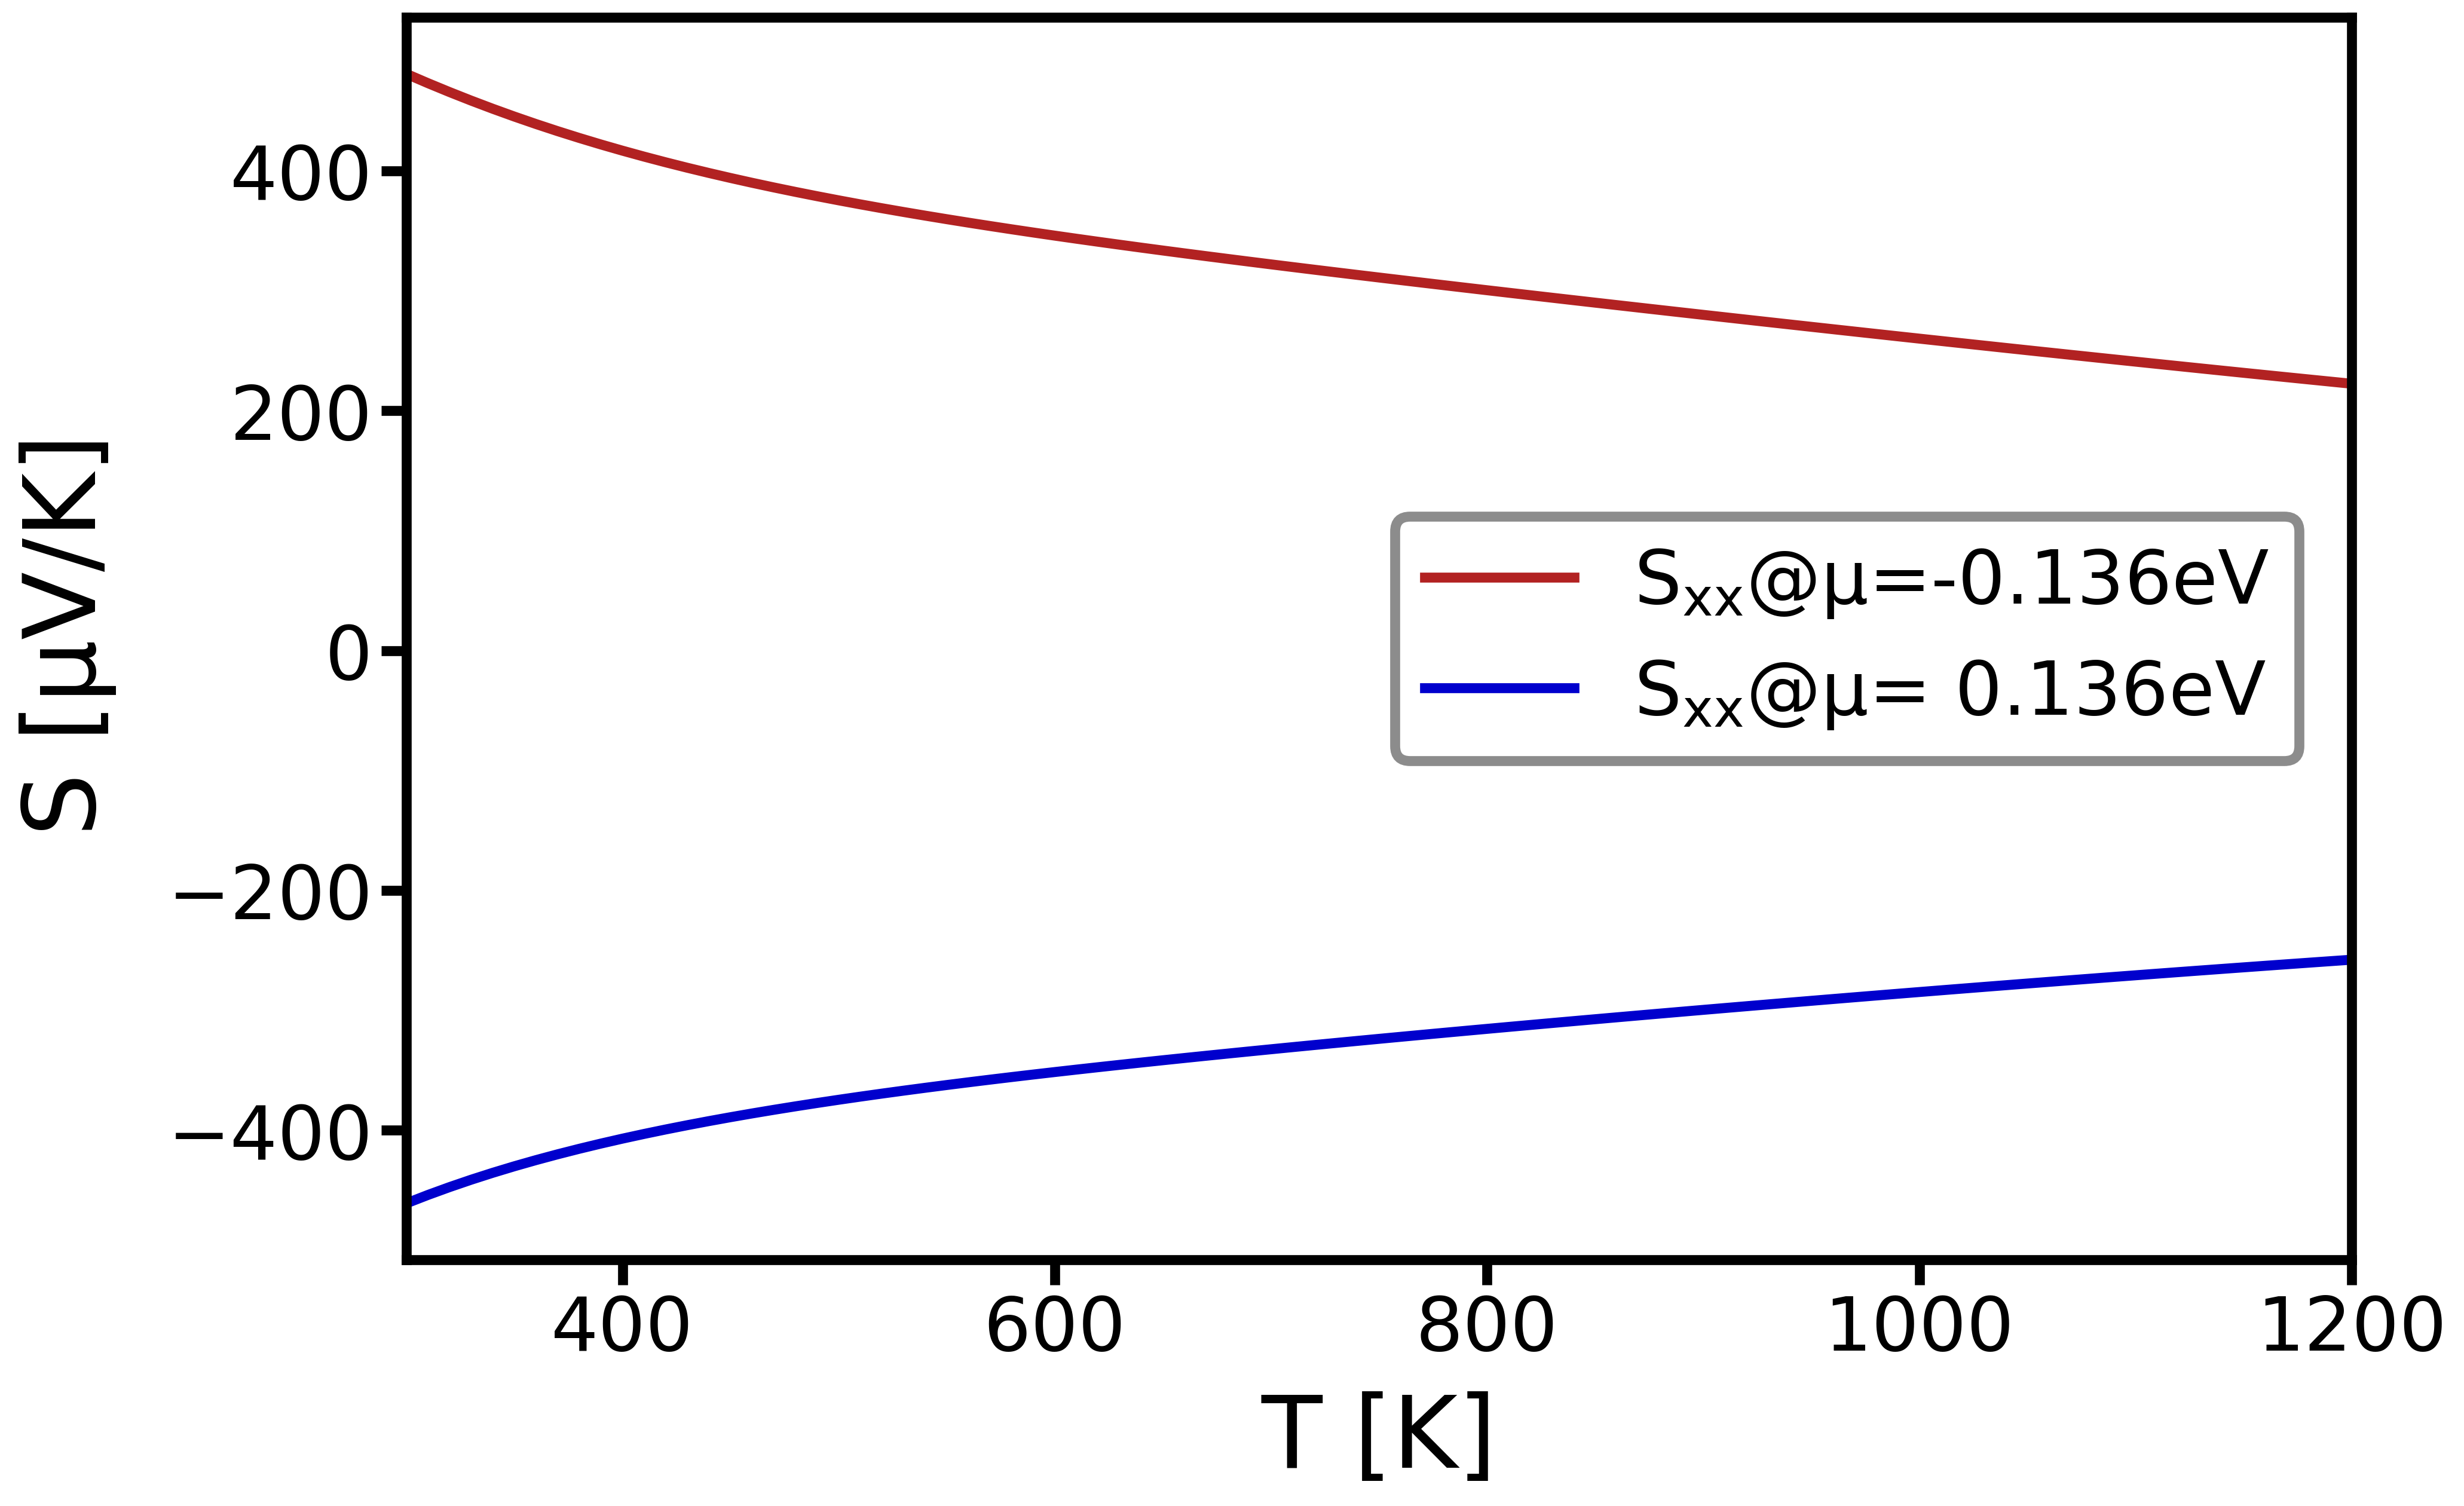
</figure>

Again, <span style="color:red">**using τ = 10 fs**</span>, the electrical conductivity for these μ's is obtained as:

In [14]:
%%bash
cd BE-Si
grep ' -0.136' ELECTCOND_11.OUT > E11M
grep  ' 0.136' ELECTCOND_11.OUT > E11P
python3 -m excitingscripts.plot.files -f E11P E11M  -cy 3  -ll '$\sigma_{xx}$@$\mu$= 0.136eV' '$\sigma_{xx}$@$\mu$=-0.136eV'  -x 300 1200  -lx 'T [K]'  -ly '$\sigma$ [S/cm]'  -ys 1e-16  -rp
cd ../

Output:

<figure>
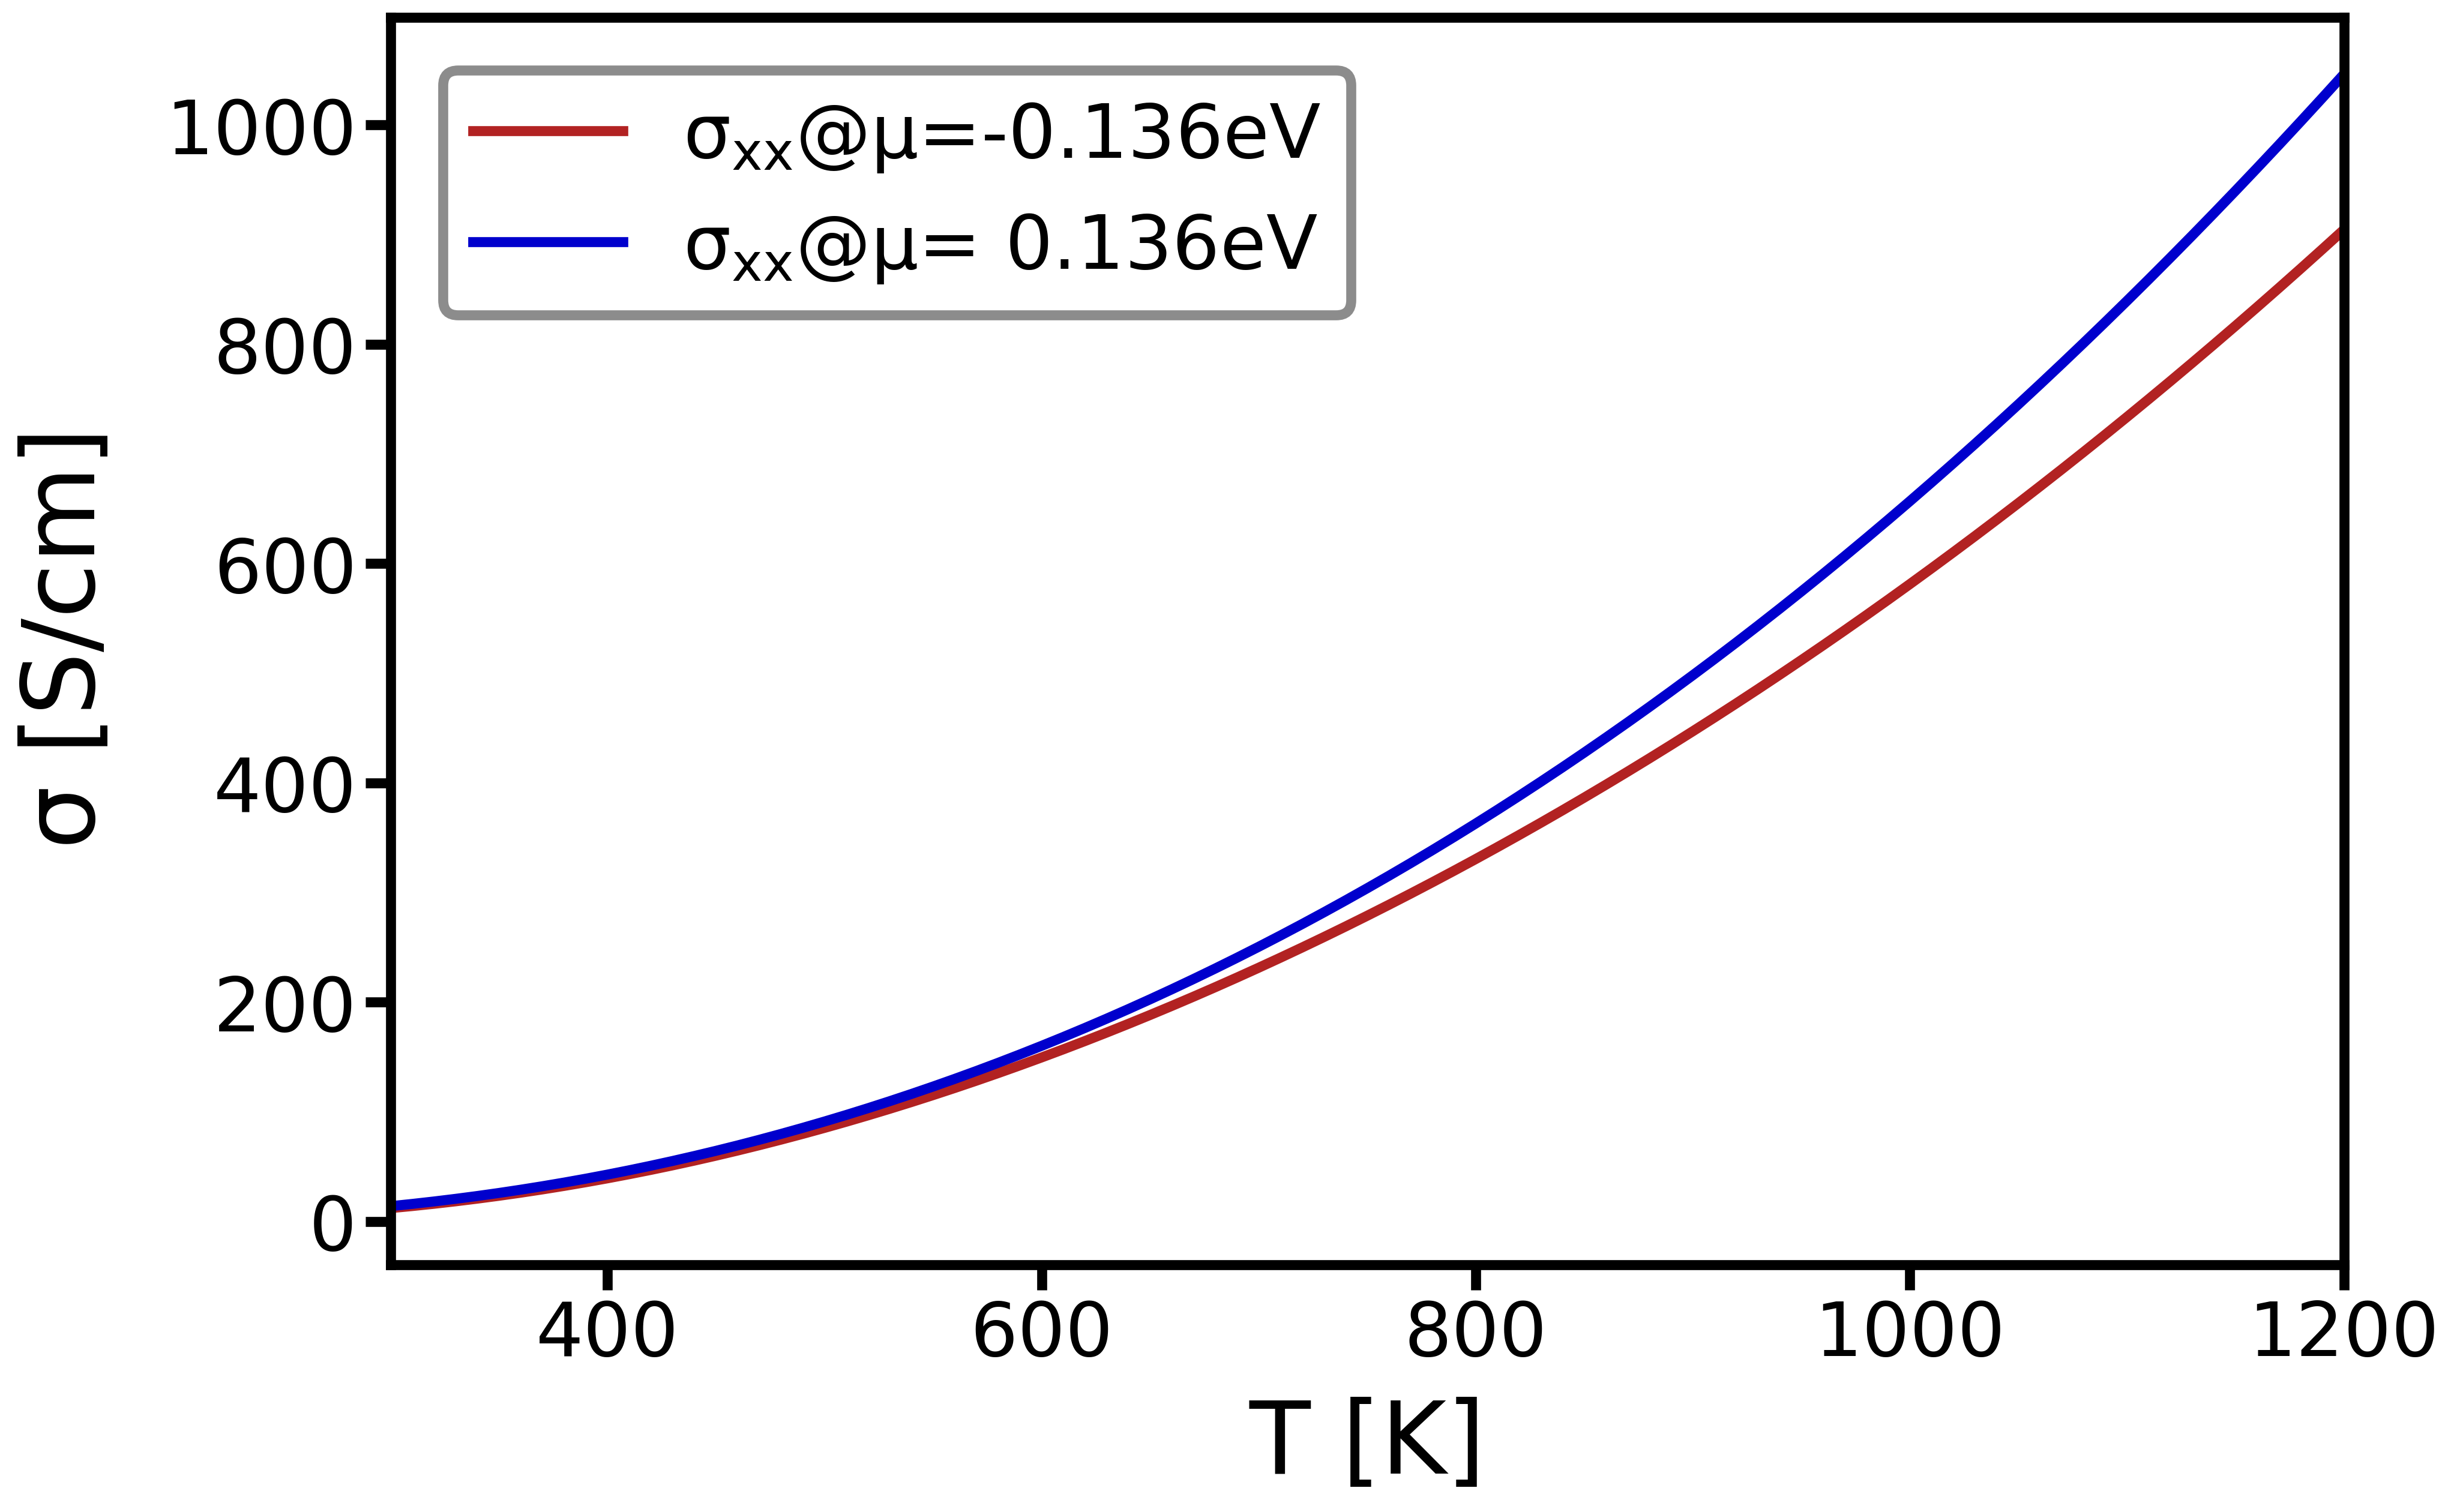
</figure>

And the corresponding power factor looks as:

In [15]:
%%bash
cd BE-Si
paste ELECTCOND_11.OUT SEEBECK_11.OUT | grep ' -0.136' | awk '{ printf $1 "\t" $2 "\t" $3*$7*$7 "\n" }' > PF11M
paste ELECTCOND_11.OUT SEEBECK_11.OUT | grep  ' 0.136' | awk '{ printf $1 "\t" $2 "\t" $3*$7*$7 "\n" }' > PF11P
python3 -m excitingscripts.plot.files -f PF11P PF11M  -cy 3  -ll '${\sigma S^2}_{xx}$@$\mu$= 0.136eV' '${\sigma S^2}_{xx}$@$\mu$=-0.136eV'  -x 300 1200  -lx 'T [K]'  -ly '$\sigma S^2$ [$\mu W\,cm^{-1}\,K^{-2}$]'  -ys 1e-10  -rp
cd ../

Output:

<figure>
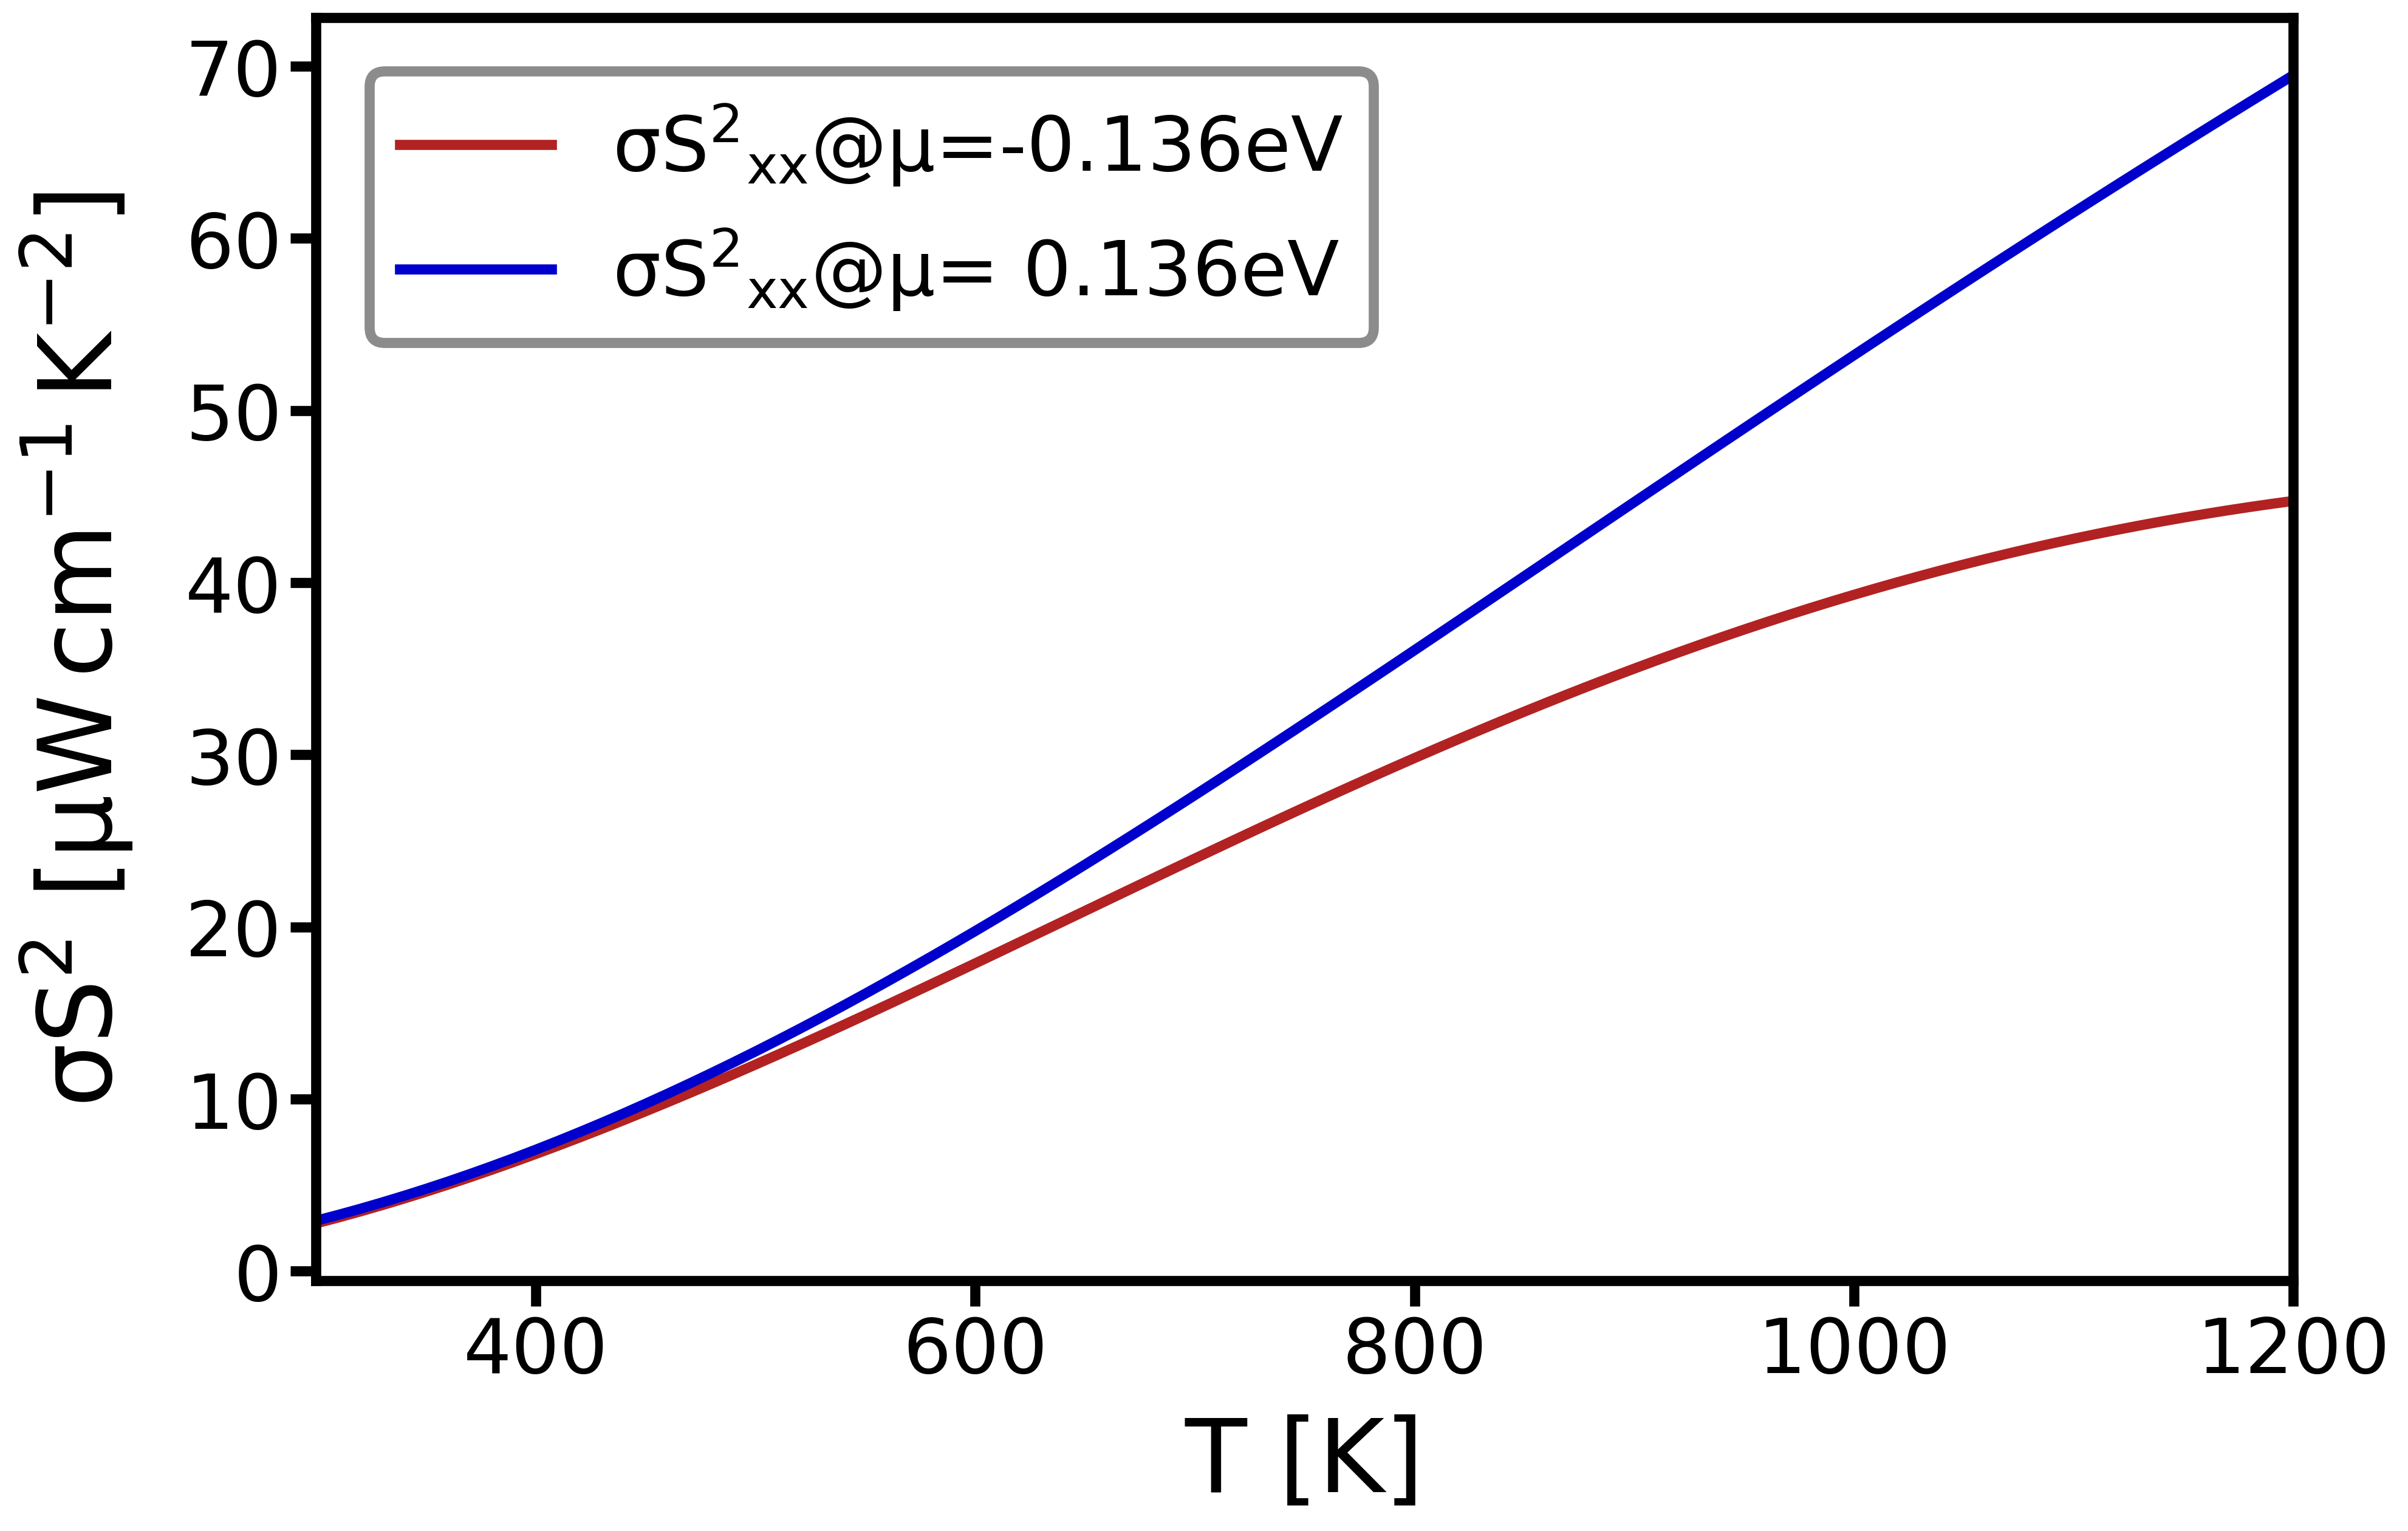
</figure>


<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">Bibliography</span>

1. <a id='r1'></a>Method described in detail in: B. R. Nag, "Electron Transport in Compound Semiconductors" (Springer Verlag, Berlin, 1996).
2. <a id='r2'></a>G. D. Mahan and J. O. Sofo, "The best thermoelectric", Proc. Natl. Aad. Sci. USA <b>93</b>, 7436 (1996).
3. <a id='r3'></a>T. J. Scheidemantel, C. Ambrosch-Draxl, T. Thonhauser, H. V. Badding, and J. O. Sofo, "Transport coefficients from first-rinciples calculations", Phys. Rev. B <b>68</b>, 125210 (2003).


<hr style="border:2px solid #DDD"> </hr>